Epoch 1/10
17/17 [==============================] - 41s 2s/step - loss: 0.3818 - accuracy: 0.9277 - val_loss: 0.1629 - val_accuracy: 0.9875
Epoch 2/10
17/17 [==============================] - 44s 3s/step - loss: 0.1490 - accuracy: 0.9874 - val_loss: 0.1291 - val_accuracy: 0.9875
Epoch 3/10
17/17 [==============================] - 41s 2s/step - loss: 0.1208 - accuracy: 0.9874 - val_loss: 0.1168 - val_accuracy: 0.9875
Epoch 4/10
17/17 [==============================] - 41s 2s/step - loss: 0.1104 - accuracy: 0.9874 - val_loss: 0.1108 - val_accuracy: 0.9875
Epoch 5/10
17/17 [==============================] - 136s 8s/step - loss: 0.1035 - accuracy: 0.9874 - val_loss: 0.1068 - val_accuracy: 0.9875
Epoch 6/10
17/17 [==============================] - 41s 2s/step - loss: 0.0995 - accuracy: 0.9874 - val_loss: 0.1050 - val_accuracy: 0.9875
Epoch 7/10
17/17 [==============================] - 41s 2s/step - loss: 0.0961 - accuracy: 0.9874 - val_loss: 0.0982 - val_accuracy: 0.9875
Epoch 8/10
17/17 [=

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


Skipping image 1: no segmented areas in mask.
Skipping image 2: no segmented areas in mask.
Skipping image 3: no segmented areas in mask.
Skipping image 4: no segmented areas in mask.
Skipping image 5: no segmented areas in mask.
Skipping image 6: no segmented areas in mask.
Skipping image 7: no segmented areas in mask.
Skipping image 8: no segmented areas in mask.
Skipping image 9: no segmented areas in mask.
Skipping image 10: no segmented areas in mask.
Skipping image 11: no segmented areas in mask.
Skipping image 12: no segmented areas in mask.
Skipping image 13: no segmented areas in mask.
Skipping image 14: no segmented areas in mask.
Skipping image 15: no segmented areas in mask.
Skipping image 16: no segmented areas in mask.
Skipping image 17: no segmented areas in mask.
Skipping image 18: no segmented areas in mask.
Skipping image 19: no segmented areas in mask.
Skipping image 20: no segmented areas in mask.
Skipping image 21: no segmented areas in mask.
Skipping image 22: no 

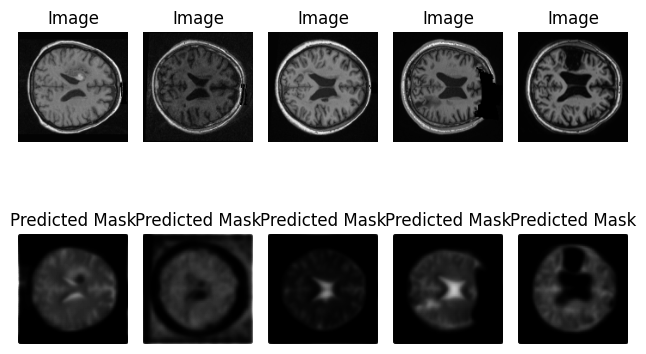

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from radiomics import featureextractor
import SimpleITK as sitk

# Function to load NIfTI images 
def load_nifti_image(subject_dir, filename_pattern):
    file_list = glob.glob(os.path.join(subject_dir, filename_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching {filename_pattern} in {subject_dir}")
    img = nib.load(file_list[0])
    return img.get_fdata()

# Preprocess image
def preprocess_image(image_data, target_size=(128, 128)):
    image_data = (image_data - np.min(image_data)) / (np.max(image_data) - np.min(image_data) + 1e-8)
    middle_slice = image_data[:, :, image_data.shape[2] // 2]
    return tf.image.resize(middle_slice[..., np.newaxis], target_size)

# Prepare data
def prepare_data(data_dir, target_size=(128, 128)):
    images, masks = [], []
    r0_dirs = glob.glob(os.path.join(data_dir, 'R0*/sub-*/ses-1/anat'))
    for img_dir in r0_dirs:
        try:
            img_data = load_nifti_image(img_dir, 'sub-*_T1w.nii.gz')
            img_preprocessed = preprocess_image(img_data, target_size)
            images.append(img_preprocessed.numpy())

            mask_data = load_nifti_image(img_dir, 'sub-*_label-L_desc-T1lesion_mask.nii.gz')
            mask_preprocessed = preprocess_image(mask_data, target_size)
            masks.append(mask_preprocessed.numpy())
        except FileNotFoundError:
            continue
    return np.array(images), np.array(masks)

# Load data
data_dir_train = '/Users/olayinkaajao/Downloads/ATLAS_2/Training'
X, y = prepare_data(data_dir_train)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define U-Net model
def unet_model(input_shape=(128, 128, 1), regularized=False):
    inputs = layers.Input(input_shape)
    reg = regularizers.l2(1e-4) if regularized else None

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)
    pool1 = layers.Dropout(0.3)(pool1) if regularized else pool1

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)
    pool2 = layers.Dropout(0.3)(pool2) if regularized else pool2

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', kernel_regularizer=reg)(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', kernel_regularizer=reg)(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(conv5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train U-Net models
unet_regularized = unet_model(regularized=True)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=1, restore_best_weights=True)

# Train models
unet_regularized.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Predict masks using U-Net
predicted_masks = unet_regularized.predict(X_val)

# PyRadiomics Feature Extraction
def extract_radiomics_features(images, masks, extractor):
    features = []
    feature_names = None

    for i, (img, mask) in enumerate(zip(images, masks)):
        img_sitk = sitk.GetImageFromArray(img.squeeze())
        mask_binary = (mask.squeeze() > 0.5).astype(np.uint8)
        mask_sitk = sitk.GetImageFromArray(mask_binary)

        if np.sum(mask_binary) == 0:
            print(f"Skipping image {i + 1}: no segmented areas in mask.")
            continue

        feature_vector = extractor.execute(img_sitk, mask_sitk)

        if feature_names is None:
            feature_names = list(feature_vector.keys())
        
        features.append(list(feature_vector.values()))

    if features and feature_names:
        return pd.DataFrame(features, columns=feature_names)
    else:
        return pd.DataFrame()  # Return empty DataFrame

# Extract radiomics features
extractor = featureextractor.RadiomicsFeatureExtractor()
radiomics_features_df = extract_radiomics_features(X_val, predicted_masks, extractor)

# Display radiomics features
if not radiomics_features_df.empty:
    print("Radiomics Features DataFrame:")
    print(radiomics_features_df.head())
else:
    print("No valid radiomics features extracted.")

# Save to CSV
radiomics_features_df.to_csv("radiomics_features.csv", index=False)


import matplotlib.pyplot as plt

# Visualization function for selected radiomics features
def visualize_radiomics_features(radiomics_df, image_index, feature_keys):
    """
    Visualize selected radiomics features for a specific image.

    Parameters:
    - radiomics_df: DataFrame of radiomics features extracted.
    - image_index: Index of the image in the DataFrame.
    - feature_keys: List of feature keys to visualize.
    """
    if radiomics_df.empty:
        print("No valid radiomics features to visualize.")
        return

    if image_index >= len(radiomics_df):
        print(f"Invalid image index: {image_index}. Max index is {len(radiomics_df) - 1}.")
        return

    print(f"Visualizing features for Image {image_index + 1}")
    
    plt.figure(figsize=(12, 6))
    for idx, key in enumerate(feature_keys):
        if key not in radiomics_df.columns:
            print(f"Feature '{key}' not found in the DataFrame.")
            continue

        plt.subplot(1, len(feature_keys), idx + 1)
        plt.bar(range(len(radiomics_df)), radiomics_df[key])
        plt.title(key)
        plt.xlabel("Image Index")
        plt.ylabel("Value")
        plt.grid()

    plt.tight_layout()
    plt.show()


# Define the keys of features you want to visualize
selected_features = [
    "original_firstorder_Mean", 
    "original_shape_Volume", 
    "original_glcm_Contrast"
]

# Call the visualization function
visualize_radiomics_features(radiomics_features_df, image_index=0, feature_keys=selected_features)
# Visualize segmented images
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[i].squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(predicted_masks[i].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()


5/5 [==============================] - 3s 594ms/step

Test Metrics:
      Metric     Value
0   Accuracy  0.988924
1  Precision  0.000000
2     Recall  0.000000
3   F1 Score  0.000000


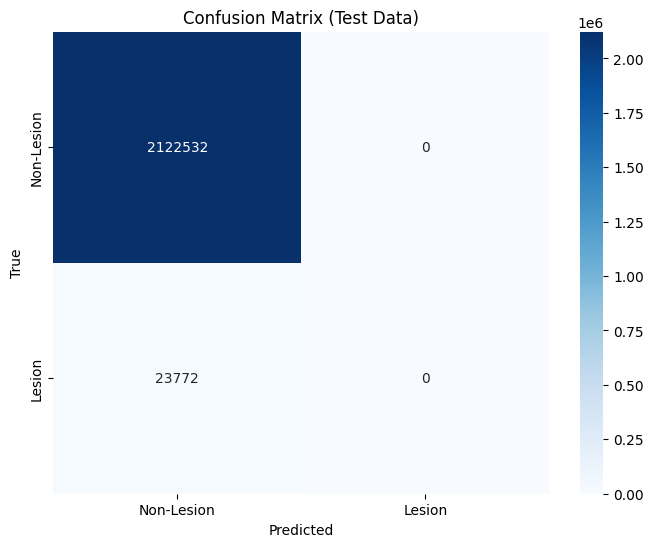

In [5]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Function to evaluate U-Net model on test data
def evaluate_unet_on_test(test_images, test_masks, model):
    # Generate predictions
    predicted_masks = model.predict(test_images)

    # Flatten the true and predicted masks for evaluation
    y_true_flat = (test_masks > 0.5).astype(int).flatten()
    y_pred_flat = (predicted_masks > 0.5).astype(int).flatten()

    # Compute metrics
    test_accuracy = accuracy_score(y_true_flat, y_pred_flat)
    test_precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    test_recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    test_f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
    test_confusion_matrix = confusion_matrix(y_true_flat, y_pred_flat)

    # Print metrics
    print("\nTest Metrics:")
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Value': [test_accuracy, test_precision, test_recall, test_f1]
    })
    print(metrics_df)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Lesion', 'Lesion'], yticklabels=['Non-Lesion', 'Lesion'])
    plt.title('Confusion Matrix (Test Data)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return metrics_df

# Example Usage:
# Assuming `X_test` and `y_test` are your test images and masks
# Ensure `unet_regularized` is your trained U-Net model
test_metrics = evaluate_unet_on_test(X_val, y_val, unet_regularized)

# Save metrics to a CSV file
test_metrics.to_csv("unet_test_metrics.csv", index=False)


Epoch 1/30
33/33 [==============================] - 45s 1s/step - loss: 0.4145 - accuracy: 0.9864 - val_loss: 0.1214 - val_accuracy: 0.9875
Epoch 2/30
33/33 [==============================] - 46s 1s/step - loss: 0.0984 - accuracy: 0.9874 - val_loss: 0.0703 - val_accuracy: 0.9875
Epoch 3/30
33/33 [==============================] - 45s 1s/step - loss: 0.0632 - accuracy: 0.9874 - val_loss: 0.0728 - val_accuracy: 0.9875
Epoch 4/30
33/33 [==============================] - 45s 1s/step - loss: 0.0583 - accuracy: 0.9874 - val_loss: 0.0667 - val_accuracy: 0.9875
Epoch 5/30
33/33 [==============================] - 46s 1s/step - loss: 0.0561 - accuracy: 0.9874 - val_loss: 0.0711 - val_accuracy: 0.9875
Epoch 6/30
33/33 [==============================] - 45s 1s/step - loss: 0.0578 - accuracy: 0.9874 - val_loss: 0.0655 - val_accuracy: 0.9875
Epoch 7/30
33/33 [==============================] - 46s 1s/step - loss: 0.0555 - accuracy: 0.9874 - val_loss: 0.0717 - val_accuracy: 0.9875
Epoch 8/30
33/33 [==

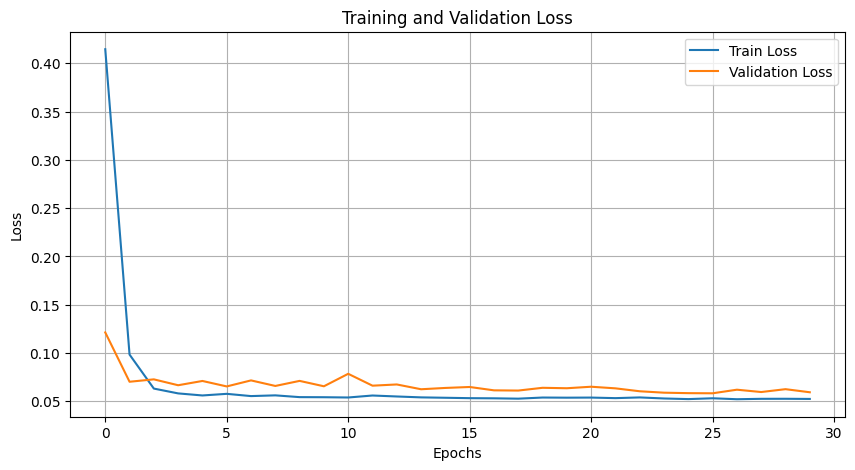

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import MeanIoU

# Weighted Binary Cross-Entropy Loss
def weighted_binary_crossentropy(weight):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)  # Ensure y_true is float32
        bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
        weight_map = tf.where(tf.equal(y_true, 1), tf.constant(weight, dtype=tf.float32), tf.constant(1.0, dtype=tf.float32))
        return tf.reduce_mean(bce * weight_map)
    return loss


# Define Improved U-Net Model
def improved_unet_model(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)
    pool1 = layers.Dropout(0.3)(pool1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)
    pool2 = layers.Dropout(0.3)(pool2)

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=weighted_binary_crossentropy(weight=5),
        metrics=['accuracy']
    )
    return model

# Initialize the Model
improved_unet = improved_unet_model()

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

# Train the Model
history = improved_unet.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=16,
    callbacks=[early_stopping]
)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()






Test Accuracy: 0.9889242157681297
Test Precision: 1.0
Test Recall: 0.0
Test F1 Score: 0.0


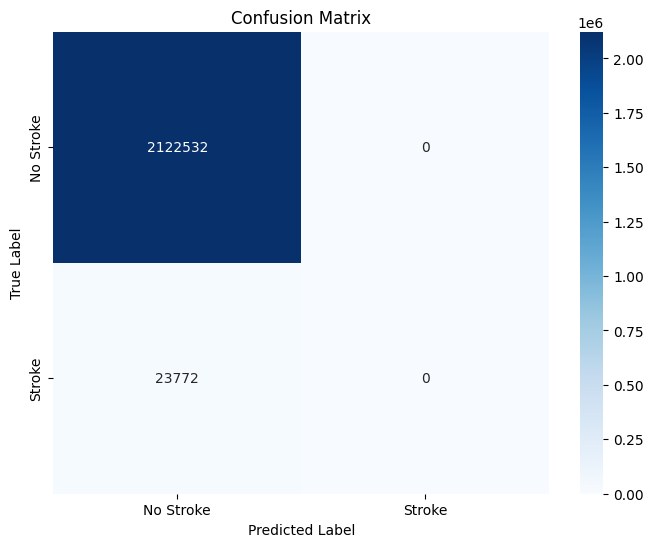

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import seaborn as sns

# Threshold predictions to binary values
threshold = 0.5
y_pred_binary = (y_pred > threshold).astype(int).flatten()  # Convert predictions to binary
y_true_binary = (y_val.flatten() > threshold).astype(int)  # Ensure ground truth is binary

# Compute metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=1)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=1)
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=1)

# Print metrics
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test F1 Score: {f1}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



Loading data...


INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radi

Initializing feature extractor...
Extracting radiomics features...
Skipping image 1: no segmented areas in mask.
Skipping image 2: no segmented areas in mask.
Skipping image 3: no segmented areas in mask.
Skipping image 4: no segmented areas in mask.
Skipping image 5: no segmented areas in mask.
Skipping image 6: no segmented areas in mask.
Skipping image 7: no segmented areas in mask.
Skipping image 8: no segmented areas in mask.
Skipping image 9: no segmented areas in mask.
Skipping image 10: no segmented areas in mask.
Skipping image 11: no segmented areas in mask.
Skipping image 12: no segmented areas in mask.
Skipping image 14: no segmented areas in mask.
Skipping image 15: no segmented areas in mask.
Skipping image 16: no segmented areas in mask.
Skipping image 17: no segmented areas in mask.
Skipping image 18: no segmented areas in mask.
Skipping image 19: no segmented areas in mask.
Skipping image 20: no segmented areas in mask.
Skipping image 21: no segmented areas in mask.
Sk

INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding 

Skipping image 130: no segmented areas in mask.
Skipping image 131: no segmented areas in mask.
Skipping image 132: no segmented areas in mask.
Skipping image 133: no segmented areas in mask.
Skipping image 134: no segmented areas in mask.
Skipping image 135: no segmented areas in mask.
Skipping image 136: no segmented areas in mask.
Skipping image 137: no segmented areas in mask.
Skipping image 138: no segmented areas in mask.
Skipping image 139: no segmented areas in mask.
Skipping image 141: no segmented areas in mask.
Skipping image 142: no segmented areas in mask.
Skipping image 143: no segmented areas in mask.
Skipping image 144: no segmented areas in mask.
Skipping image 145: no segmented areas in mask.
Skipping image 146: no segmented areas in mask.
Skipping image 147: no segmented areas in mask.
Skipping image 148: no segmented areas in mask.
Skipping image 149: no segmented areas in mask.
Skipping image 150: no segmented areas in mask.
Skipping image 151: no segmented areas i

...

Skipping image 307: no segmented areas in mask.
Skipping image 308: no segmented areas in mask.
Skipping image 309: no segmented areas in mask.
Skipping image 311: no segmented areas in mask.
Skipping image 312: no segmented areas in mask.
Skipping image 313: no segmented areas in mask.
Skipping image 314: no segmented areas in mask.
Skipping image 315: no segmented areas in mask.
Skipping image 316: no segmented areas in mask.
Skipping image 317: no segmented areas in mask.
Skipping image 318: no segmented areas in mask.
Skipping image 320: no segmented areas in mask.
Skipping image 321: no segmented areas in mask.
Skipping image 322: no segmented areas in mask.
Skipping image 323: no segmented areas in mask.
Skipping image 324: no segmented areas in mask.
Skipping image 325: no segmented areas in mask.
Skipping image 326: no segmented areas in mask.
Skipping image 327: no segmented areas in mask.
Skipping image 328: no segmented areas in mask.
Skipping image 329: no segmented areas i

INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to

Skipping image 397: no segmented areas in mask.
Skipping image 398: no segmented areas in mask.
Skipping image 399: no segmented areas in mask.
Skipping image 400: no segmented areas in mask.
Skipping image 401: no segmented areas in mask.
Skipping image 402: no segmented areas in mask.
Skipping image 403: no segmented areas in mask.
Skipping image 404: no segmented areas in mask.
Skipping image 405: no segmented areas in mask.
Skipping image 406: no segmented areas in mask.
Error processing image 407: mask only contains 1 segmented voxel! Cannot extract features for a single voxel.
Skipping image 408: no segmented areas in mask.
Skipping image 409: no segmented areas in mask.
Skipping image 410: no segmented areas in mask.
Skipping image 411: no segmented areas in mask.
Skipping image 412: no segmented areas in mask.
Skipping image 414: no segmented areas in mask.
Error processing image 415: mask has too few dimensions (number of dimensions 1, minimum required 2)
Skipping image 416: n

Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INF

Skipping image 583: no segmented areas in mask.
Skipping image 585: no segmented areas in mask.
Skipping image 586: no segmented areas in mask.
Skipping image 587: no segmented areas in mask.
Skipping image 588: no segmented areas in mask.
Skipping image 589: no segmented areas in mask.
Skipping image 590: no segmented areas in mask.
Skipping image 591: no segmented areas in mask.
Skipping image 592: no segmented areas in mask.
Skipping image 593: no segmented areas in mask.
Skipping image 594: no segmented areas in mask.
Skipping image 595: no segmented areas in mask.
Skipping image 596: no segmented areas in mask.
Skipping image 597: no segmented areas in mask.
Error processing image 598: mask has too few dimensions (number of dimensions 1, minimum required 2)
Skipping image 599: no segmented areas in mask.
Error processing image 600: mask has too few dimensions (number of dimensions 1, minimum required 2)
Skipping image 603: no segmented areas in mask.
Skipping image 604: no segment

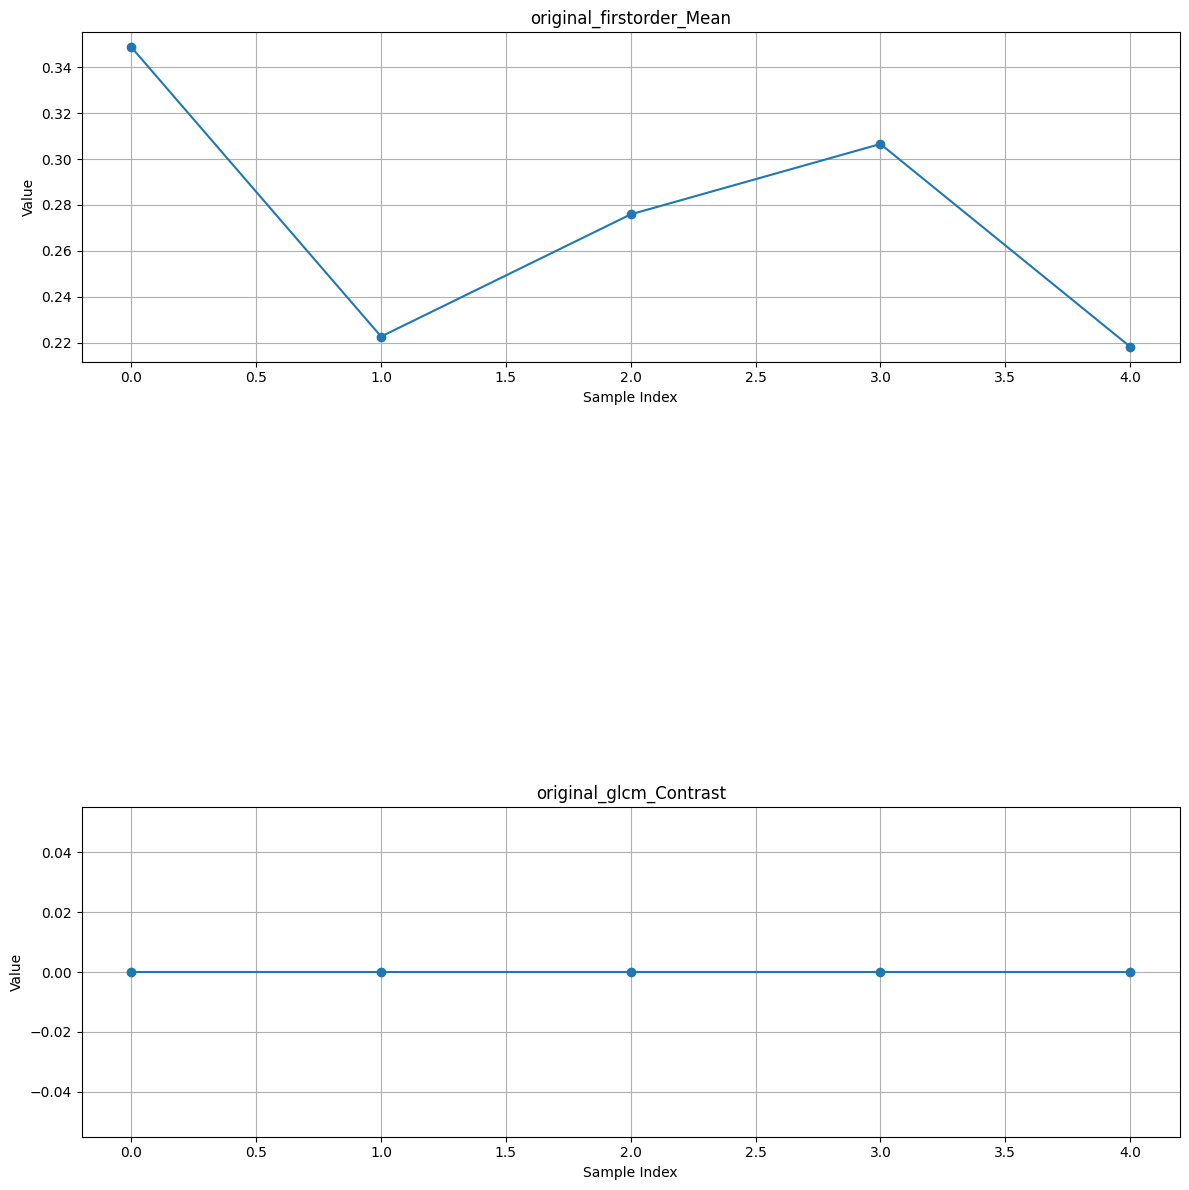

In [32]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from radiomics import featureextractor

# Function to load NIfTI images
def load_nifti_image(subject_dir, filename_pattern):
    file_list = glob.glob(os.path.join(subject_dir, filename_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching {filename_pattern} in {subject_dir}")
    img = sitk.ReadImage(file_list[0])
    return img

# Preprocess image
def preprocess_image(image_data, target_size=(128, 128)):
    array = sitk.GetArrayFromImage(image_data)
    normalized_array = (array - np.min(array)) / (np.max(array) - np.min(array) + 1e-8)
    middle_slice = normalized_array[:, :, normalized_array.shape[2] // 2]
    resized_image = tf.image.resize(middle_slice[..., np.newaxis], target_size)
    return resized_image

# Prepare data
def prepare_data(data_dir, target_size=(128, 128)):
    images, masks = [], []
    r0_dirs = glob.glob(os.path.join(data_dir, 'R0*/sub-*/ses-1/anat'))
    for img_dir in r0_dirs:
        try:
            img_data = load_nifti_image(img_dir, 'sub-*_T1w.nii.gz')
            img_preprocessed = preprocess_image(img_data, target_size)
            images.append(img_preprocessed.numpy())

            mask_data = load_nifti_image(img_dir, 'sub-*_label-L_desc-T1lesion_mask.nii.gz')
            mask_preprocessed = preprocess_image(mask_data, target_size)
            masks.append(mask_preprocessed.numpy())
        except FileNotFoundError:
            continue
    return np.array(images), np.array(masks)

# Radiomics Feature Extraction with Mask Validation
def extract_radiomics_features(images, masks, extractor):
    features = []
    feature_names = None

    for i, (img, mask) in enumerate(zip(images, masks)):
        # Convert to SimpleITK images
        img_sitk = sitk.GetImageFromArray(img.squeeze())
        mask_binary = (mask.squeeze() > 0.5).astype(np.uint8)
        mask_sitk = sitk.GetImageFromArray(mask_binary)

        # Validate the mask
        if np.sum(mask_binary) == 0:
            print(f"Skipping image {i + 1}: no segmented areas in mask.")
            continue
        if mask_sitk.GetDimension() < 2:
            print(f"Skipping image {i + 1}: mask has insufficient dimensions.")
            continue

        try:
            feature_vector = extractor.execute(img_sitk, mask_sitk)
            if feature_names is None:
                feature_names = list(feature_vector.keys())
            features.append(list(feature_vector.values()))
        except Exception as e:
            print(f"Error processing image {i + 1}: {e}")
            continue

    return pd.DataFrame(features, columns=feature_names) if features else pd.DataFrame()

# Define directories for data
data_dir_train = '/Users/olayinkaajao/Downloads/ATLAS_2/Training'

# Load the data
print("Loading data...")
X, y = prepare_data(data_dir_train)

# Initialize PyRadiomics feature extractor
print("Initializing feature extractor...")
extractor = featureextractor.RadiomicsFeatureExtractor()

# Extract radiomics features
print("Extracting radiomics features...")
radiomics_features_df = extract_radiomics_features(X, y, extractor)

# Display radiomics features
if not radiomics_features_df.empty:
    print("Radiomics Features DataFrame:")
    print(radiomics_features_df.head())
else:
    print("No valid radiomics features extracted.")

# Save to CSV
print("Saving features to 'radiomics_features.csv'...")
radiomics_features_df.to_csv("radiomics_features.csv", index=False)

# Visualize selected radiomics features
def visualize_radiomics_features(radiomics_df, feature_keys, num_samples=5):
    """
    Visualize radiomics features across samples.
    
    Parameters:
    - radiomics_df: DataFrame containing radiomics features.
    - feature_keys: List of feature names to visualize.
    - num_samples: Number of images to plot features for.
    """
    if radiomics_df.empty:
        print("No valid radiomics features to visualize.")
        return

    plt.figure(figsize=(12, len(feature_keys) * 4))
    for idx, key in enumerate(feature_keys):
        if key not in radiomics_df.columns:
            print(f"Feature '{key}' not found in the DataFrame.")
            continue

        plt.subplot(len(feature_keys), 1, idx + 1)
        plt.plot(radiomics_df[key][:num_samples], marker='o')
        plt.title(key)
        plt.xlabel("Sample Index")
        plt.ylabel("Value")
        plt.grid()

    plt.tight_layout()
    plt.show()

# Define features to visualize
selected_features = [
    "original_firstorder_Mean", 
    "original_shape_Volume", 
    "original_glcm_Contrast"
]

# Visualize the features
print("Visualizing selected features...")
visualize_radiomics_features(radiomics_features_df, selected_features, num_samples=5)


5/5 [==============================] - 0s 24ms/step


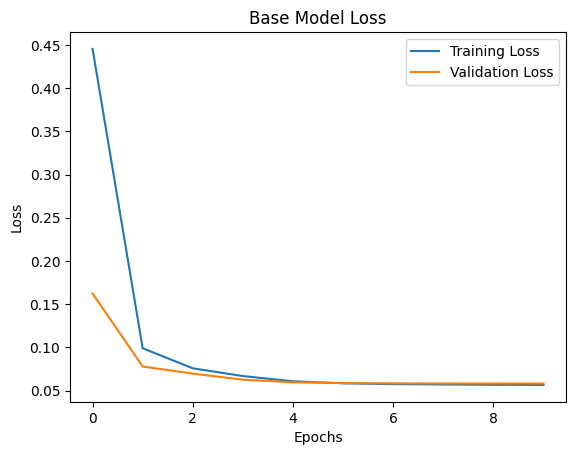

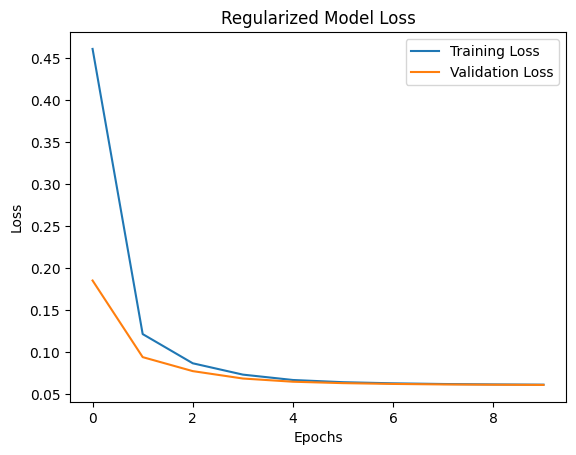

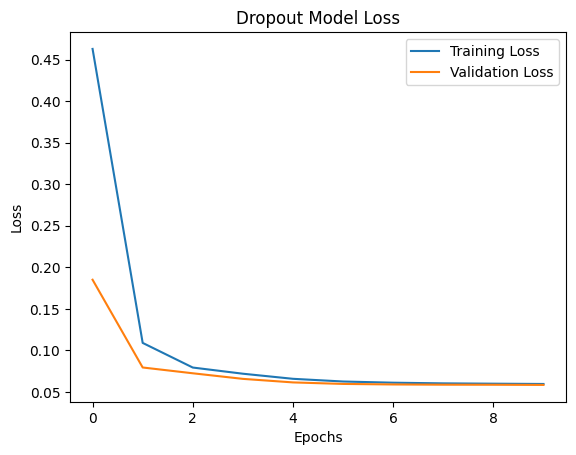

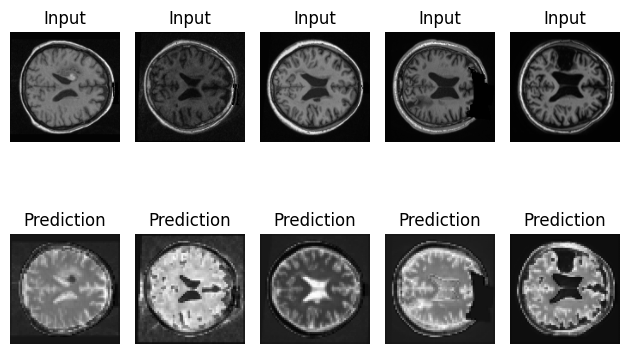


Model Performance Summary:
      Model  Train Loss  Validation Loss  Accuracy
       Base    0.056644         0.058274  0.988924
Regularized    0.061511         0.061209  0.988924
    Dropout    0.059619         0.058476  0.988924


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define model variants
def create_models(input_shape=(128, 128, 1)):
    # Base model
    def build_base_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(p1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Regularized model (without dropout)
    def build_regularized_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer='l2')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(p1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Dropout model
    def build_dropout_model():
        inputs = Input(input_shape)
        c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
        p1 = MaxPooling2D((2, 2))(c1)
        d1 = Dropout(0.5)(p1)
        u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d1)
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(u1)
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    return build_base_model(), build_regularized_model(), build_dropout_model()



# Generate models
base_model, regularized_model, dropout_model = create_models()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train models
# Train models
models_data = {}
for model_name, model in zip(['Base', 'Regularized', 'Dropout'], [base_model, regularized_model, dropout_model]):
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=16, callbacks=[early_stopping], verbose=0)
    predictions = model.predict(X_val)
    y_pred_binary = (predictions > 0.5).astype(int)
    y_val_binary = (y_val > 0.5).astype(int)  # Convert ground truth to binary
    metrics = {
        'train_loss': history.history['loss'][-1],
        'val_loss': history.history['val_loss'][-1],
        'accuracy': accuracy_score(y_val_binary.flatten(), y_pred_binary.flatten()),
        'precision': precision_score(y_val_binary.flatten(), y_pred_binary.flatten(), zero_division=0),
        'f1_score': f1_score(y_val_binary.flatten(), y_pred_binary.flatten(), zero_division=0)
    }
    models_data[model_name] = {'model': model, 'history': history, 'metrics': metrics, 'predictions': predictions}



# Plot training and validation loss
for model_name, data in models_data.items():
    history = data['history']
    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Display predictions
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val[i].squeeze(), cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(models_data['Base']['predictions'][i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Create summary table
summary_data = {
    "Model": [],
    "Train Loss": [],
    "Validation Loss": [],
  
    "Accuracy": []

}

for model_name, data in models_data.items():
    metrics = data['metrics']
    summary_data["Model"].append(model_name)
    summary_data["Train Loss"].append(metrics['train_loss'])
    summary_data["Validation Loss"].append(metrics['val_loss'])
    #summary_data["Precision"].append(metrics['precision'])
    summary_data["Accuracy"].append(metrics['accuracy'])
   # summary_data["F1 Score"].append(metrics['f1_score'])

# Convert summary data to a pandas DataFrame
summary_df = pd.DataFrame(summary_data)

# Print summary table
print("\nModel Performance Summary:")
print(summary_df.to_string(index=False))


# Display summary as a styled DataFrame
#import ace_tools as tools; tools.display_dataframe_to_user(name="Model Performance Summary", dataframe=summary_df)


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import os
import gc
import tifffile as tiff
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, jaccard_score



def highlight(row):
    df = lambda x: ['background: #CCCCFF' if x.name in row
                        else '' for i in x]
    return df

def metrics_table(gt_masks, pred_masks):
    metrics = {'Precision':[],'Recall':[],'Accuracy':[],'Dice':[],'IoU':[]}
    for i, (mask, pred) in enumerate(zip(gt_masks, pred_masks)):
        metrics['Precision'].append(precision_score_(mask, pred))
        metrics['Recall'].append(recall_score_(mask, pred))
        metrics['Accuracy'].append(accuracy(mask, pred))
        metrics['Dice'].append(dice_coef(mask, pred))
        metrics['IoU'].append(iou(mask, pred))
    df = pd.DataFrame.from_dict(metrics)
    df.columns = ['Precision', 'Recall', 'Accuracy', 'Dice', 'IoU']
    return df


DEMO_SHAPE = (5,5)
gt_mask_0 = np.zeros(DEMO_SHAPE, dtype=np.float32)
for i in range(DEMO_SHAPE[0]):
    gt_mask_0[i:i+2,i:i+2] = 1.0
pred_mask_0 = gt_mask_0.copy()
pred_mask_0[1:4,2:4] = 0.


df = pd.read_csv('/Users/olayinkaajao/Downloads/radiomics_features.csv')
df.head()

radiomics_features
diagnostics_Versions_PyRadiomics diagnostics_Versions_Numpy diagnostics_Versions_SimpleITK diagnostics_Versions_PyWavelet diagnostics_Versions_Python diagnostics_Configuration_Settings                 diagnostics_Configuration_EnabledImageTypes diagnostics_Image-original_Hash          diagnostics_Image-original_Dimensionality diagnostics_Image-original_Spacing diagnostics_Image-original_Size diagnostics_Image-original_Mean diagnostics_Image-original_Minimum diagnostics_Image-original_Maximum diagnostics_Mask-original_Hash           diagnostics_Mask-original_Spacing diagnostics_Mask-original_Size diagnostics_Mask-original_BoundingBox diagnostics_Mask-original_VoxelNum diagnostics_Mask-original_VolumeNum diagnostics_Mask-original_CenterOfMassIndex diagnostics_Mask-original_CenterOfMass original_firstorder_10Percentile original_firstorder_90Percentile original_firstorder_Energy original_firstorder_Entropy original_firstorder_InterquartileRange original_firstorder_Kurtosis original_firstorder_Maximum original_firstorder_MeanAbsoluteDeviation original_firstorder_Mean original_firstorder_Median original_firstorder_Minimum original_firstorder_Range original_firstorder_RobustMeanAbsoluteDeviation original_firstorder_RootMeanSquared original_firstorder_Skewness original_firstorder_TotalEnergy original_firstorder_Uniformity original_firstorder_Variance original_glcm_Autocorrelation original_glcm_ClusterProminence original_glcm_ClusterShade original_glcm_ClusterTendency original_glcm_Contrast original_glcm_Correlation original_glcm_DifferenceAverage original_glcm_DifferenceEntropy original_glcm_DifferenceVariance original_glcm_Id original_glcm_Idm original_glcm_Idmn original_glcm_Idn original_glcm_Imc1 original_glcm_Imc2 original_glcm_InverseVariance original_glcm_JointAverage original_glcm_JointEnergy original_glcm_JointEntropy original_glcm_MCC original_glcm_MaximumProbability original_glcm_SumAverage original_glcm_SumEntropy original_glcm_SumSquares original_gldm_DependenceEntropy original_gldm_DependenceNonUniformity original_gldm_DependenceNonUniformityNormalized original_gldm_DependenceVariance original_gldm_GrayLevelNonUniformity original_gldm_GrayLevelVariance original_gldm_HighGrayLevelEmphasis original_gldm_LargeDependenceEmphasis original_gldm_LargeDependenceHighGrayLevelEmphasis original_gldm_LargeDependenceLowGrayLevelEmphasis original_gldm_LowGrayLevelEmphasis original_gldm_SmallDependenceEmphasis original_gldm_SmallDependenceHighGrayLevelEmphasis original_gldm_SmallDependenceLowGrayLevelEmphasis original_glrlm_GrayLevelNonUniformity original_glrlm_GrayLevelNonUniformityNormalized original_glrlm_GrayLevelVariance original_glrlm_HighGrayLevelRunEmphasis original_glrlm_LongRunEmphasis original_glrlm_LongRunHighGrayLevelEmphasis original_glrlm_LongRunLowGrayLevelEmphasis original_glrlm_LowGrayLevelRunEmphasis original_glrlm_RunEntropy original_glrlm_RunLengthNonUniformity original_glrlm_RunLengthNonUniformityNormalized original_glrlm_RunPercentage original_glrlm_RunVariance original_glrlm_ShortRunEmphasis original_glrlm_ShortRunHighGrayLevelEmphasis original_glrlm_ShortRunLowGrayLevelEmphasis original_glszm_GrayLevelNonUniformity original_glszm_GrayLevelNonUniformityNormalized original_glszm_GrayLevelVariance original_glszm_HighGrayLevelZoneEmphasis original_glszm_LargeAreaEmphasis original_glszm_LargeAreaHighGrayLevelEmphasis original_glszm_LargeAreaLowGrayLevelEmphasis original_glszm_LowGrayLevelZoneEmphasis original_glszm_SizeZoneNonUniformity original_glszm_SizeZoneNonUniformityNormalized original_glszm_SmallAreaEmphasis original_glszm_SmallAreaHighGrayLevelEmphasis original_glszm_SmallAreaLowGrayLevelEmphasis original_glszm_ZoneEntropy original_glszm_ZonePercentage original_glszm_ZoneVariance original_ngtdm_Busyness original_ngtdm_Coarseness original_ngtdm_Complexity original_ngtdm_Contrast  original_ngtdm_Strength
3.1.0a2.post22+g39aaa77          1.24.3                     2.4.0                        

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import os
import gc
import tifffile as tiff
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, jaccard_score



def highlight(row):
    df = lambda x: ['background: #CCCCFF' if x.name in row
                        else '' for i in x]
    return df

def metrics_table(gt_masks, pred_masks):
    metrics = {'Precision':[],'Recall':[],'Accuracy':[],'Dice':[],'IoU':[]}
    for i, (mask, pred) in enumerate(zip(gt_masks, pred_masks)):
        metrics['Precision'].append(precision_score_(mask, pred))
        metrics['Recall'].append(recall_score_(mask, pred))
        metrics['Accuracy'].append(accuracy(mask, pred))
        metrics['Dice'].append(dice_coef(mask, pred))
        metrics['IoU'].append(iou(mask, pred))
    df = pd.DataFrame.from_dict(metrics)
    df.columns = ['Precision', 'Recall', 'Accuracy', 'Dice', 'IoU']
    return df


DEMO_SHAPE = (5,5)
gt_mask_0 = np.zeros(DEMO_SHAPE, dtype=np.float32)
for i in range(DEMO_SHAPE[0]):
    gt_mask_0[i:i+2,i:i+2] = 1.0
pred_mask_0 = gt_mask_0.copy()
pred_mask_0[1:4,2:4] = 0.


df = pd.read_csv('/Users/olayinkaajao/Downloads/radiomics_features.csv')
df.head()




def precision_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_pixel_pred = np.sum(pred_mask)
    precision = np.mean(intersect/total_pixel_pred)
    return round(precision, 3)



def recall_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_pixel_truth = np.sum(groundtruth_mask)
    recall = np.mean(intersect/total_pixel_truth)
    return round(recall, 3)


def accuracy(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    xor = np.sum(groundtruth_mask==pred_mask)
    acc = np.mean(xor/(union + xor - intersect))
    return round(acc, 3)



def dice_coef(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    total_sum = np.sum(pred_mask) + np.sum(groundtruth_mask)
    dice = np.mean(2*intersect/total_sum)
    return round(dice, 3) #round up to 3 decimal places


def iou(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask*groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    iou = np.mean(intersect/union)
    return round(iou, 3)


compare_masks(gt_mask_0, pred_mask_0)

In [13]:
pip install tifffile


Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install gc

ERROR: Could not find a version that satisfies the requirement gc (from versions: none)
ERROR: No matching distribution found for gc
Note: you may need to restart the kernel to use updated packages.


In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import os
import gc
import tifffile as tiff
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, jaccard_score


def highlight(row):
    # Highlight rows based on certain conditions
    return ['background: #CCCCFF' if i else '' for i in row]


def metrics_table(gt_masks, pred_masks):
    # Compute metrics for a list of ground truth and predicted masks
    metrics = {'Precision': [], 'Recall': [], 'Accuracy': [], 'Dice': [], 'IoU': []}
    for mask, pred in zip(gt_masks, pred_masks):
        metrics['Precision'].append(precision_score_(mask, pred))
        metrics['Recall'].append(recall_score_(mask, pred))
        metrics['Accuracy'].append(accuracy(mask, pred))
        metrics['Dice'].append(dice_coef(mask, pred))
        metrics['IoU'].append(iou(mask, pred))
    df = pd.DataFrame(metrics)
    return df


# Demo masks for testing
DEMO_SHAPE = (5, 5)
gt_mask_0 = np.zeros(DEMO_SHAPE, dtype=np.float32)
for i in range(DEMO_SHAPE[0] - 1):  # Adjusted range to avoid out-of-bounds
    gt_mask_0[i:i + 2, i:i + 2] = 1.0
pred_mask_0 = gt_mask_0.copy()
pred_mask_0[1:4, 2:4] = 0.

# Functions to compute individual metrics
def precision_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    total_pixel_pred = np.sum(pred_mask)
    if total_pixel_pred == 0:  # Avoid division by zero
        return 0.0
    precision = intersect / total_pixel_pred
    return round(precision, 3)


def recall_score_(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    total_pixel_truth = np.sum(groundtruth_mask)
    if total_pixel_truth == 0:  # Avoid division by zero
        return 0.0
    recall = intersect / total_pixel_truth
    return round(recall, 3)


def accuracy(groundtruth_mask, pred_mask):
    total_pixels = groundtruth_mask.size
    correct = np.sum(groundtruth_mask == pred_mask)
    acc = correct / total_pixels
    return round(acc, 3)


def dice_coef(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    total_sum = np.sum(pred_mask) + np.sum(groundtruth_mask)
    if total_sum == 0:  # Avoid division by zero
        return 0.0
    dice = 2 * intersect / total_sum
    return round(dice, 3)


def iou(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    if union == 0:  # Avoid division by zero
        return 0.0
    iou = intersect / union
    return round(iou, 3)


# Example comparison
def compare_masks(gt_mask, pred_mask):
    metrics = {
        'Precision': precision_score_(gt_mask, pred_mask),
        'Recall': recall_score_(gt_mask, pred_mask),
        'Accuracy': accuracy(gt_mask, pred_mask),
        'Dice': dice_coef(gt_mask, pred_mask),
        'IoU': iou(gt_mask, pred_mask)
    }
    print("Metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value}")


# Test comparison
compare_masks(gt_mask_0, pred_mask_0)


Metrics:
Precision: 1.0
Recall: 0.6150000095367432
Accuracy: 0.8
Dice: 0.762
IoU: 0.6150000095367432


Epoch 1/40
50/50 [==============================] - 116s 2s/step - loss: 0.5604 - accuracy: 0.9689 - val_loss: 0.5210 - val_accuracy: 0.9875
Epoch 2/40
50/50 [==============================] - 115s 2s/step - loss: 0.5196 - accuracy: 0.9874 - val_loss: 0.5197 - val_accuracy: 0.9875
Epoch 3/40
50/50 [==============================] - 116s 2s/step - loss: 0.5170 - accuracy: 0.9874 - val_loss: 0.5183 - val_accuracy: 0.9875
Epoch 4/40
50/50 [==============================] - 116s 2s/step - loss: 0.5158 - accuracy: 0.9874 - val_loss: 0.5128 - val_accuracy: 0.9875
Epoch 5/40
50/50 [==============================] - 1159s 24s/step - loss: 0.5126 - accuracy: 0.9874 - val_loss: 0.5081 - val_accuracy: 0.9875
Epoch 6/40
50/50 [==============================] - 633s 13s/step - loss: 0.5119 - accuracy: 0.9874 - val_loss: 0.5223 - val_accuracy: 0.9875
Epoch 7/40
50/50 [==============================] - 116s 2s/step - loss: 0.5100 - accuracy: 0.9872 - val_loss: 0.5096 - val_accuracy: 0.9875
Epoch 8/40

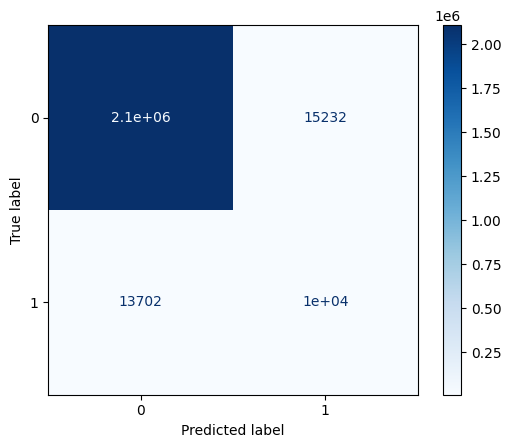

1/1 [==============================] - 0s 97ms/step


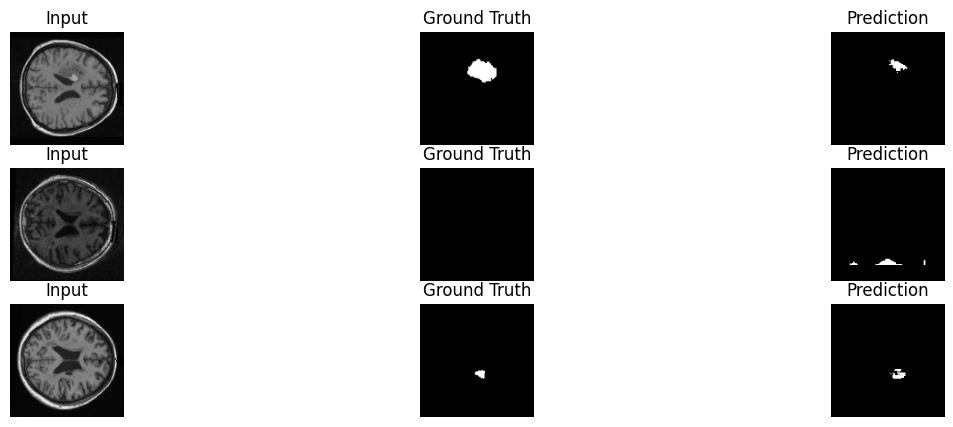

In [69]:
import os
import glob
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, jaccard_score, accuracy_score
import matplotlib.pyplot as plt

# Function to load NIfTI image based on filename pattern
def load_nifti_image(subject_dir, filename_pattern):
    file_list = glob.glob(os.path.join(subject_dir, filename_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching {filename_pattern} in {subject_dir}")
    img = nib.load(file_list[0])
    return img.get_fdata()

# Preprocess image function for U-Net input
def preprocess_image(image_data, target_size=(128, 128)):
    image_data = (image_data - np.min(image_data)) / (np.max(image_data) - np.min(image_data) + 1e-8)
    middle_slice = image_data[:, :, image_data.shape[2] // 2]
    return tf.image.resize(middle_slice[..., np.newaxis], target_size)

# Prepare MRI images and lesion masks for U-Net segmentation
def prepare_data(data_dir, target_size=(128, 128)):
    images = []
    masks = []

    r0_dirs = glob.glob(os.path.join(data_dir, 'R0*/sub-*/ses-1/anat'))
    
    for img_dir in r0_dirs:
        try:
            # Load and preprocess T1-weighted image
            img_data = load_nifti_image(img_dir, 'sub-*_T1w.nii.gz')
            img_preprocessed = preprocess_image(img_data, target_size=target_size)
            images.append(img_preprocessed.numpy())
            
            # Load and preprocess lesion mask
            lesion_mask_data = load_nifti_image(img_dir, 'sub-*_label-L_desc-T1lesion_mask.nii.gz')
            mask_preprocessed = preprocess_image(lesion_mask_data, target_size=target_size)
            masks.append(mask_preprocessed.numpy())
        
        except FileNotFoundError:
            continue

    return np.array(images), np.array(masks)

# Augment data
def augment_data(X, y):
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True
    )
    aug_X, aug_y = [], []
    for i in range(len(X)):
        it = datagen.flow(X[i:i+1], y[i:i+1], batch_size=1)
        for _ in range(3):  # Generate 3 augmentations per image
            aug_img, aug_mask = next(it)
            aug_X.append(aug_img[0])
            aug_y.append(aug_mask[0])
    return np.array(aug_X), np.array(aug_y)

# Custom loss function
def dice_loss(y_true, y_pred):
    smooth = 1e-5
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    return 0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

# Define U-Net model for lesion segmentation
def unet_model(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Dropout(0.5)(conv3)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(conv3)
    up1 = layers.concatenate([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(conv4)
    up2 = layers.concatenate([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy'])
    return model

# Load training data
data_dir_train = '/Users/olayinkaajao/Downloads/ATLAS_2/Training'
X, y = prepare_data(data_dir_train)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Augment training data
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Initialize and train the U-Net model
unet = unet_model()
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=1, restore_best_weights=True)
unet.fit(X_train_aug, y_train_aug, epochs=40, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Predict on the validation set
y_pred = unet.predict(X_val)

# Threshold predictions to get binary outputs
y_pred_binary = (y_pred > 0.5).astype(np.uint8)
y_val_binary = (y_val > 0.5).astype(np.uint8)

# Calculate Metrics
def calculate_metrics(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    metrics = {
        'Accuracy': accuracy_score(y_true_flat, y_pred_flat),
        'Precision': precision_score(y_true_flat, y_pred_flat),
        'Recall': recall_score(y_true_flat, y_pred_flat),
        'Dice Coefficient': f1_score(y_true_flat, y_pred_flat),
        'Jaccard Index': jaccard_score(y_true_flat, y_pred_flat)
    }
    return metrics

metrics = calculate_metrics(y_val_binary, y_pred_binary)
print("Validation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Confusion Matrix
def plot_confusion_matrix(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

plot_confusion_matrix(y_val_binary, y_pred_binary)

# Visualize predictions
def visualize_predictions(X, y_true, y_pred):
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(3, 3, i * 3 + 1)
        plt.imshow(X[i].squeeze(), cmap='gray')
        plt.title("Input")
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 2)
        plt.imshow(y_true[i].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 3)
        plt.imshow(y_pred[i].squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')
    plt.show()
# Confusion Matrix
def plot_confusion_matrix(y_true_binary, y_pred_binary):
    y_true_flat = y_true_binary.flatten()
    y_pred_flat = y_pred_binary.flatten()
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for True vs Predicted Mask")
    plt.show()

y_pred_val = (unet.predict(X_val[:3]) > 0.5).astype(np.uint8)
visualize_predictions(X_val[:3], y_val[:3], y_pred_val)
